In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
# Load data
df = pd.read_csv("military_personnel_data.csv")

# Basic info
print("Initial Data Overview:")
print(df.info())
print(df.describe())
print(df.isnull().sum())

Initial Data Overview:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 9 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Personnel_ID          300 non-null    object 
 1   Unit                  300 non-null    object 
 2   Age                   300 non-null    int64  
 3   Experience_Years      300 non-null    int64  
 4   Training_Type         300 non-null    object 
 5   Training_Score        280 non-null    float64
 6   Mission_Success_Rate  289 non-null    float64
 7   Fatigue_Level         300 non-null    int64  
 8   Attendance_Rate       300 non-null    float64
dtypes: float64(3), int64(3), object(3)
memory usage: 21.2+ KB
None
              Age  Experience_Years  Training_Score  Mission_Success_Rate  \
count  300.000000        300.000000      280.000000            289.000000   
mean    31.750000         10.046667       75.426464             71.912388   
std      7.33

In [7]:
# =======================
# 🔧 Data Cleaning
# =======================

# Fix typos in Unit column
df['Unit'] = df['Unit'].str.strip().str.capitalize()
df['Unit'] = df['Unit'].replace({'Alphaa': 'Alpha'})

# Fix typos in Training_Type
df['Training_Type'] = df['Training_Type'].replace({'Tehc': 'Tech'})

# Fill missing numeric values with column median
df['Training_Score'] = df['Training_Score'].fillna(df['Training_Score'].median())
df['Mission_Success_Rate'] = df['Mission_Success_Rate'].fillna(df['Mission_Success_Rate'].median())


After Cleaning:
Personnel_ID            0
Unit                    0
Age                     0
Experience_Years        0
Training_Type           0
Training_Score          0
Mission_Success_Rate    0
Fatigue_Level           0
Attendance_Rate         0
dtype: int64


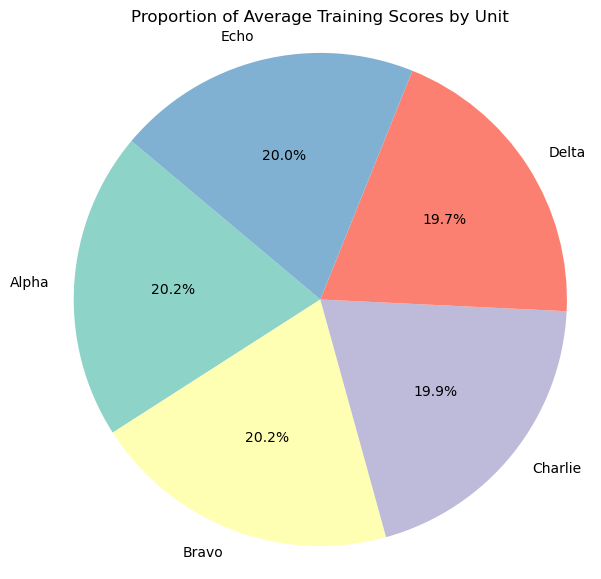

In [33]:
# Calculate average training score per unit
avg_scores = df.groupby('Unit')['Training_Score'].mean()

# Plot pie chart
plt.figure(figsize=(7,7))
plt.pie(avg_scores, labels=avg_scores.index, autopct='%1.1f%%', startangle=140, colors=sns.color_palette('Set3'))
plt.title('Proportion of Average Training Scores by Unit')
plt.axis('equal')  # Ensures pie is a circle
plt.show()

C:\Users\hasha\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
C:\Users\hasha\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
C:\Users\hasha\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):


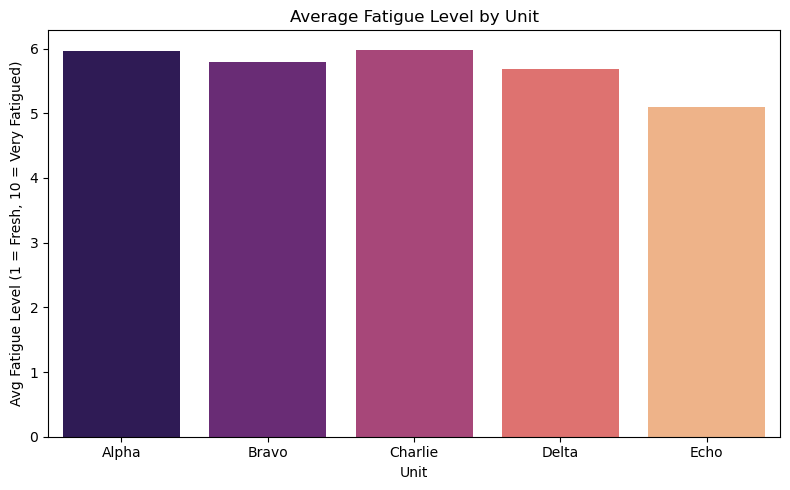

In [27]:
# Average fatigue level per unit (Bar Plot)
plt.figure(figsize=(8,5))
avg_fatigue = df.groupby('Unit')['Fatigue_Level'].mean().reset_index()
sns.barplot(x='Unit', y='Fatigue_Level', data=avg_fatigue, palette='magma')
plt.title('Average Fatigue Level by Unit')
plt.ylabel('Avg Fatigue Level (1 = Fresh, 10 = Very Fatigued)')
plt.xlabel('Unit')
plt.tight_layout()
plt.show()

C:\Users\hasha\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
C:\Users\hasha\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
C:\Users\hasha\AppData\Local\Temp\ipykernel_5672\2740678256.py:4: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.lineplot(x='Unit', y='Mission_Success_Rate', data=avg_success, palette='viridis')
C:\Users\hasha\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
C

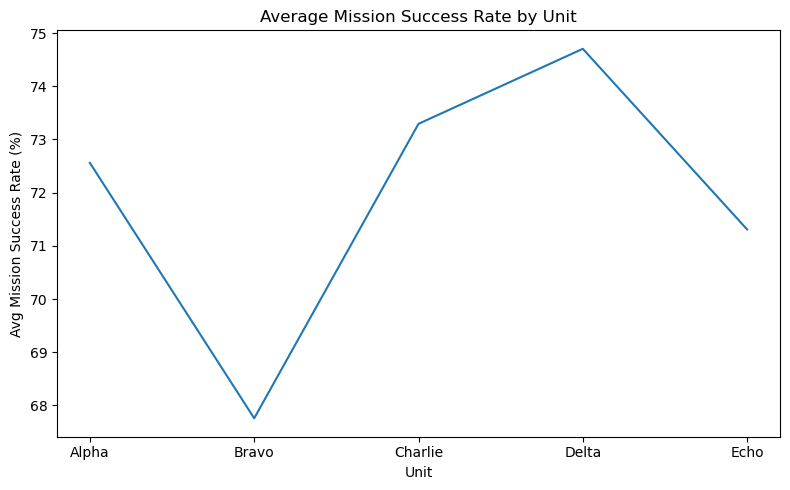

In [29]:
# Average mission success rate per unit (Bar Plot)
plt.figure(figsize=(8,5))
avg_success = df.groupby('Unit')['Mission_Success_Rate'].mean().reset_index()
sns.lineplot(x='Unit', y='Mission_Success_Rate', data=avg_success, palette='viridis')
plt.title('Average Mission Success Rate by Unit')
plt.ylabel('Avg Mission Success Rate (%)')
plt.xlabel('Unit')
plt.tight_layout()
plt.show()


In [19]:
# Group by Unit to find underperformers
unit_summary = df.groupby('Unit').agg({
    'Training_Score': 'mean',
    'Mission_Success_Rate': 'mean',
    'Fatigue_Level': 'mean',
    'Attendance_Rate': 'mean'
}).reset_index().sort_values(by='Training_Score')

print("\nPerformance Summary by Unit:")
print(unit_summary)


Performance Summary by Unit:
      Unit  Training_Score  Mission_Success_Rate  Fatigue_Level  \
3    Delta       74.151210             74.705484       5.677419   
2  Charlie       75.208772             73.294737       5.982456   
4     Echo       75.345882             71.308039       5.098039   
0    Alpha       76.121159             72.560000       5.956522   
1    Bravo       76.249754             67.757869       5.786885   

   Attendance_Rate  
3        89.445161  
2        90.539649  
4        89.788824  
0        88.852174  
1        90.676066  


In [21]:
# Flag units with below-average training or mission scores
avg_training = df['Training_Score'].mean()
avg_mission = df['Mission_Success_Rate'].mean()

underperforming_units = unit_summary[
    (unit_summary['Training_Score'] < avg_training) |
    (unit_summary['Mission_Success_Rate'] < avg_mission)
]

print("\n🚨 Units that need more training/support:")
print(underperforming_units)


🚨 Units that need more training/support:
      Unit  Training_Score  Mission_Success_Rate  Fatigue_Level  \
3    Delta       74.151210             74.705484       5.677419   
2  Charlie       75.208772             73.294737       5.982456   
4     Echo       75.345882             71.308039       5.098039   
1    Bravo       76.249754             67.757869       5.786885   

   Attendance_Rate  
3        89.445161  
2        90.539649  
4        89.788824  
1        90.676066  
